In [1]:
import os
import numpy as np
from tqdm import tqdm 
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.integrate import solve_ivp

mpl.rc('figure', figsize=(12, 6))
mpl.rc('text', usetex = False)
mpl.rc('font', family = 'serif')
mpl.rc('font', size = '14')
mpl.rc('xtick', labelsize=14) 
mpl.rc('ytick', labelsize=14)
mpl.rcParams['mathtext.fontset'] = 'stix'

In [2]:
#Definimos las direcciones de los archivos
dir = "./data/Def/"

# Scale factor $a(\tilde\eta)$

The file contains the following columns:

$\tilde\eta$ | $a$ | $a'$ | $\frac{a'}{a}$

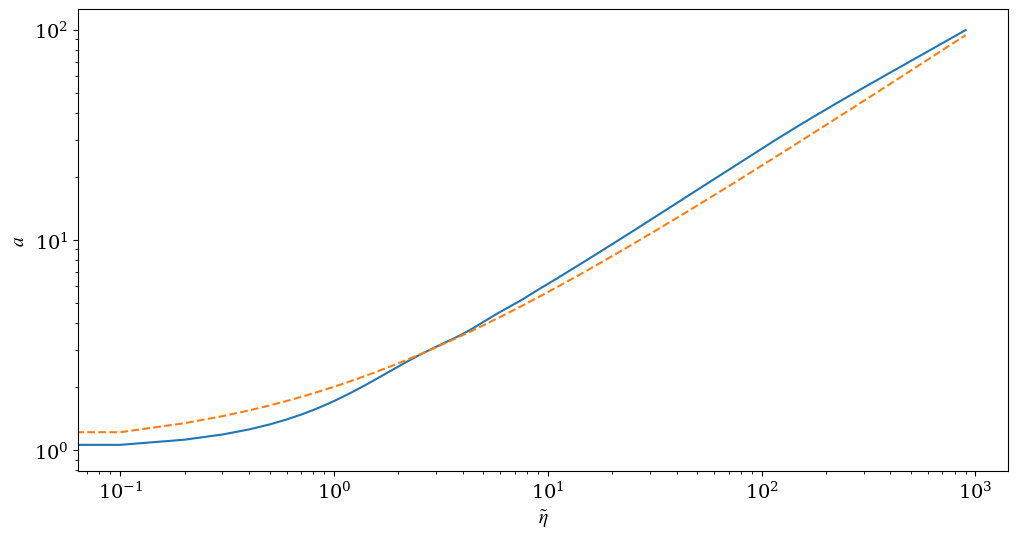

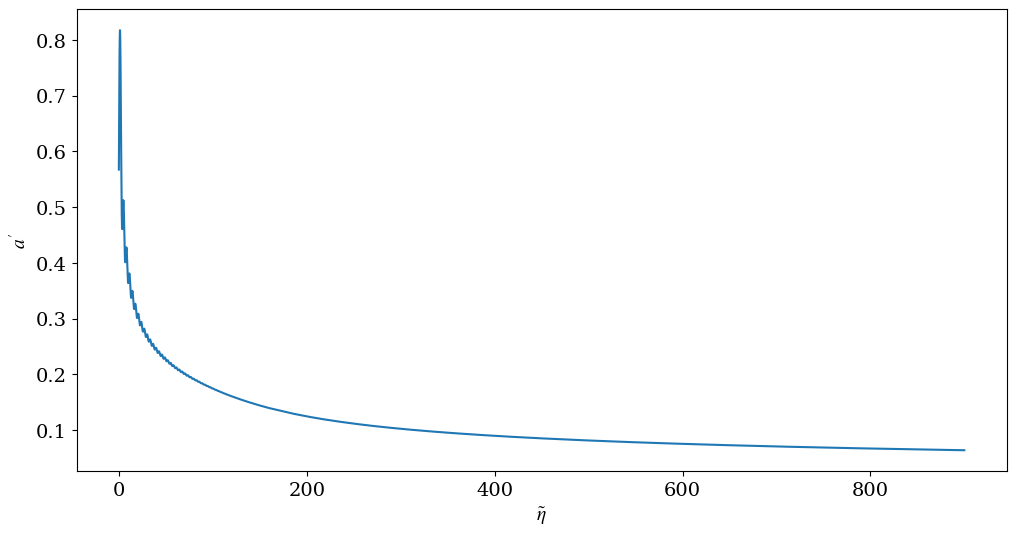

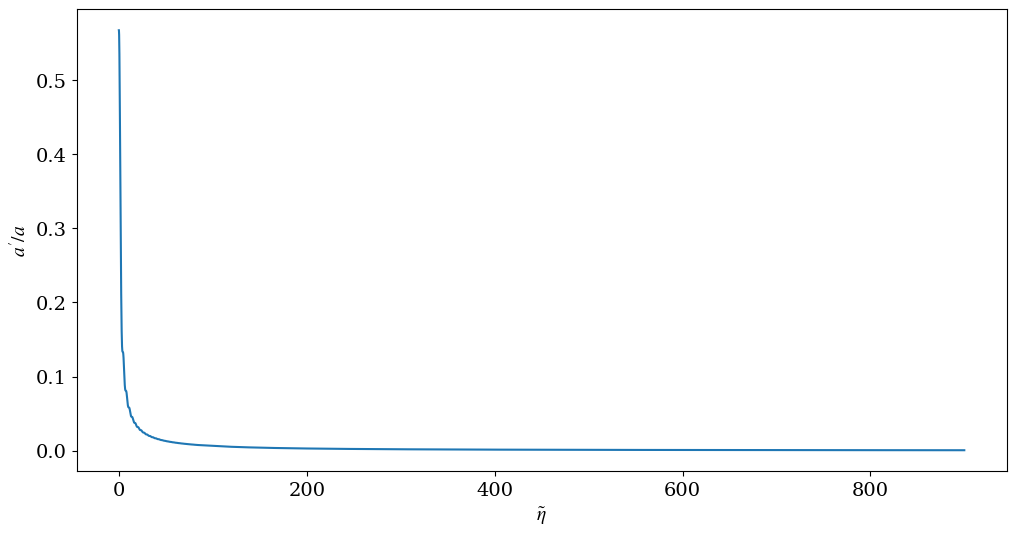

In [3]:
expansion = True

if expansion == True:
    # load the file in aDat
    aDat = np.loadtxt(dir + "average_scale_factor.txt")
    
    #plot a
    plt.figure(figsize=(12, 6))
    
    plt.plot(aDat[:,0], aDat[:,1])
    plt.plot(aDat[:,0], aDat[:,0]**(2/3)+1, "--")

    plt.ylabel("$a$")
    plt.xlabel('$\\tilde\eta$')
    plt.xscale('log')
    plt.yscale('log')


    #plot a'
    plt.figure(figsize=(12, 6))
    
    plt.plot(aDat[:,0], aDat[:,2])
    plt.ylabel(r"$a^\prime$")
    plt.xlabel(r'$\tilde\eta$')

    
    #plot a'/a
    plt.figure(figsize=(12, 6))
    
    plt.plot(aDat[:,0], aDat[:,3])
    plt.ylabel(r"$a^\prime/a$")
    plt.xlabel(r'$\tilde\eta$')
    
else:
    aDat = None

# Volume average of fields

The files for the averages of the scalar fields contain the following columns:

$\eta$ | $\langle \tilde\phi_n \rangle$ | $\langle \tilde\phi'_n \rangle$ | $\langle \tilde\phi^2_n \rangle$ | $\langle \tilde\phi^{'2}_n \rangle$ | $\mathrm{rms}(\tilde\phi_n) $ | $\mathrm{rms}(\tilde\phi'_n) $

In [4]:
# Define a function for the plots, as we are gonna do 
# the same for both fields
def plot_fld(fldDat, fldNum="", aDat=None):
    plt.plot(fldDat[:,0], fldDat[:,1])
    plt.xlabel("$\\tilde\eta$")
    plt.ylabel("$\langle\phi_"+ fldNum +"\\rangle$")
    
    if aDat is not None:
        plt.plot(fldDat[:,0], aDat[:,1] * fldDat[:,1])
        plt.xlabel("$\\tilde\eta$")
        plt.ylabel("$a\cdot\langle\phi_"+ fldNum +" \\rangle$")

## Field $0$ (inflaton)

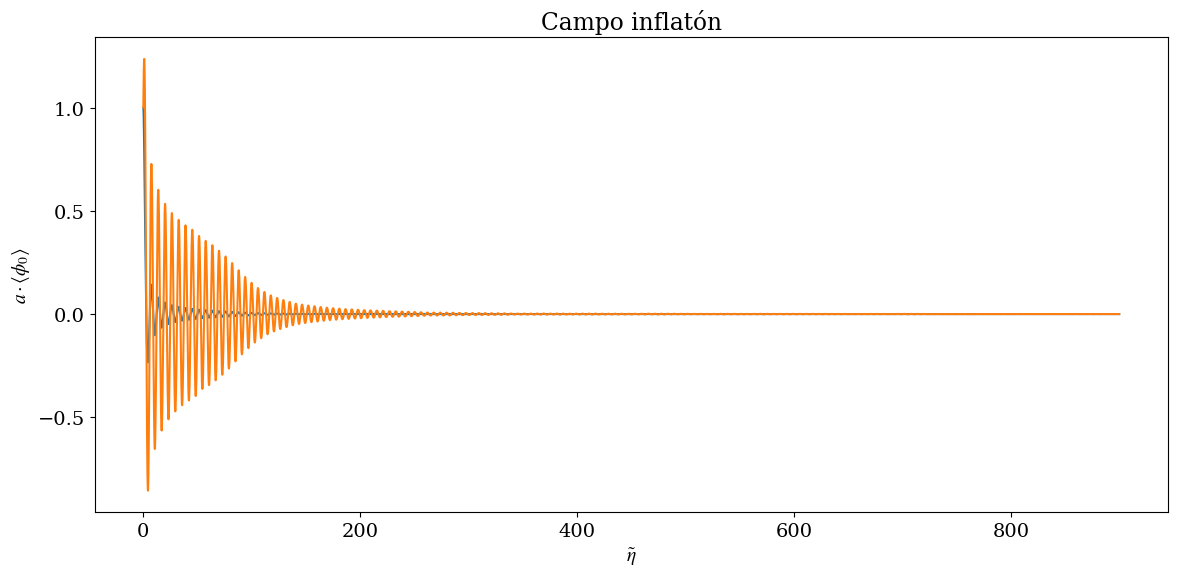

In [5]:
infDat = np.loadtxt(dir + "average_scalar_0.txt")

plt.figure(figsize=(12, 6))

plot_fld(infDat,"0",aDat)
plt.title(r'Campo inflatón')

plt.tight_layout()
plt.show()

## Field $1$ (daughter field)

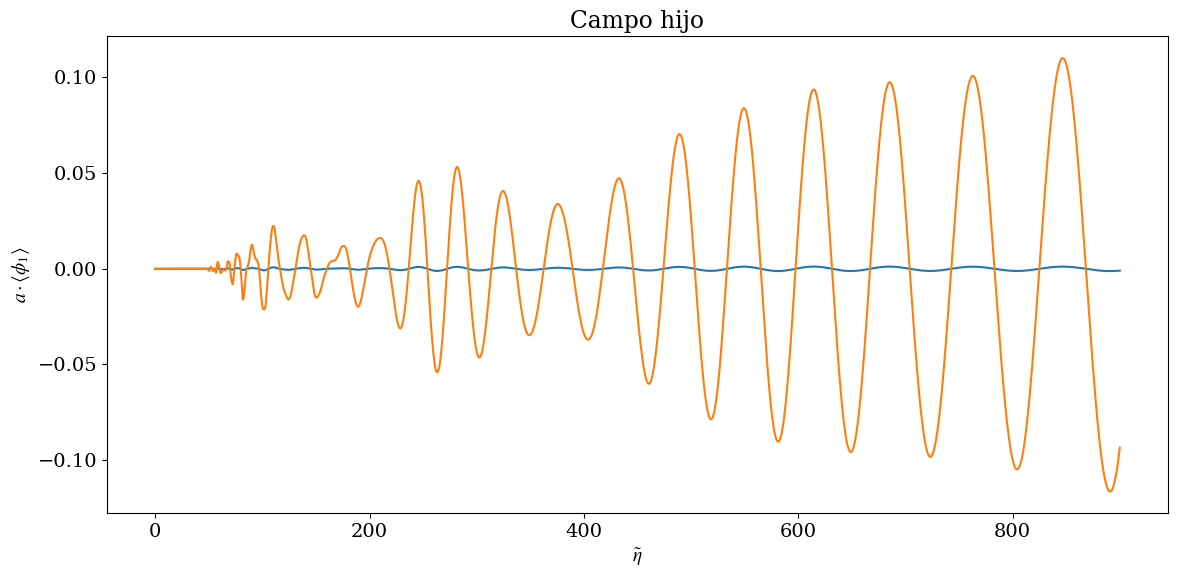

In [6]:
infDat = np.loadtxt(dir + "average_scalar_1.txt")

plt.figure(figsize=(12, 6))

plot_fld(infDat,"1",aDat)
plt.title(r'Campo hijo')

plt.tight_layout()
plt.show()

# "Energy conservation" (the $1^{st}$ Friedmann's equation is satisfied)

The file  that checks the first Friedmann's equation contains

$\tilde\eta$ | $\frac{\langle LHS - RHS\rangle}{\langle LHS + RHS\rangle}$ | $\langle LHS \rangle$ | $\langle RHS \rangle$ 

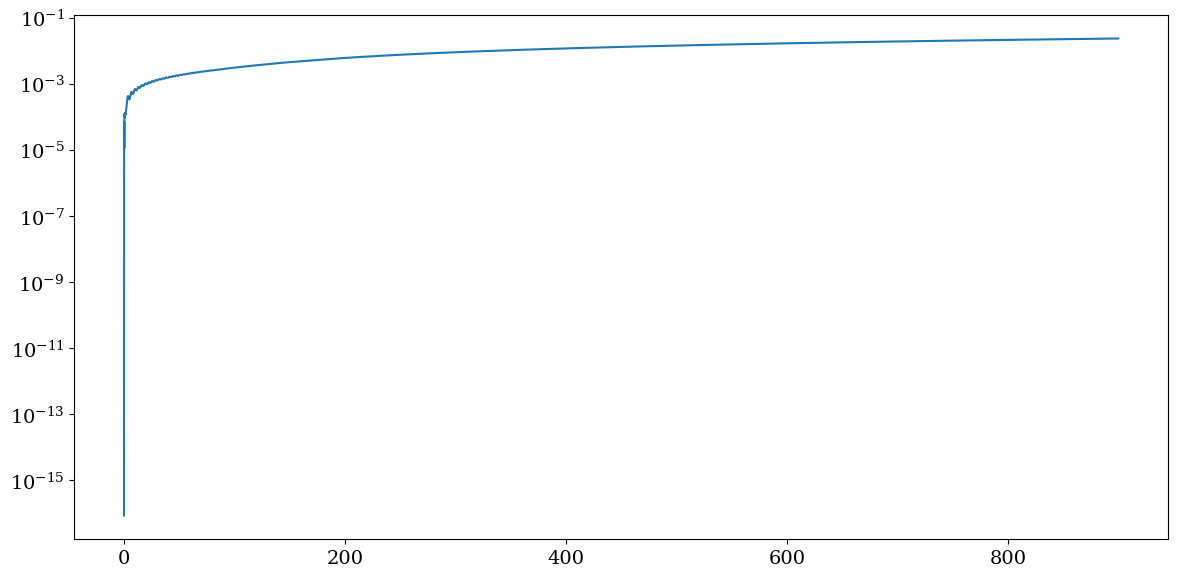

In [7]:
enConsDat = np.loadtxt(dir + "average_energy_conservation.txt")

plt.figure(figsize=(12, 6))

plt.plot(enConsDat[:,0], np.abs(enConsDat[:,1]))
plt.yscale('log')
#plt.ylim([1e-8,0.01])

plt.tight_layout()
plt.show()

# Energy densities

The file with the energy densities contains

$\tilde\eta$ | $\tilde E_K^{(0)}$ | $\tilde E_G^{(0)}$ |$\dots$| $\tilde E_K^{(N_s-1)}$ | $\tilde E_G^{(N_s-1)}$ |  $\tilde E_V^{(0)}$ | $\dots$ |  $\tilde E_V^{(N_p-1)}$ | $\langle \tilde \rho \rangle$

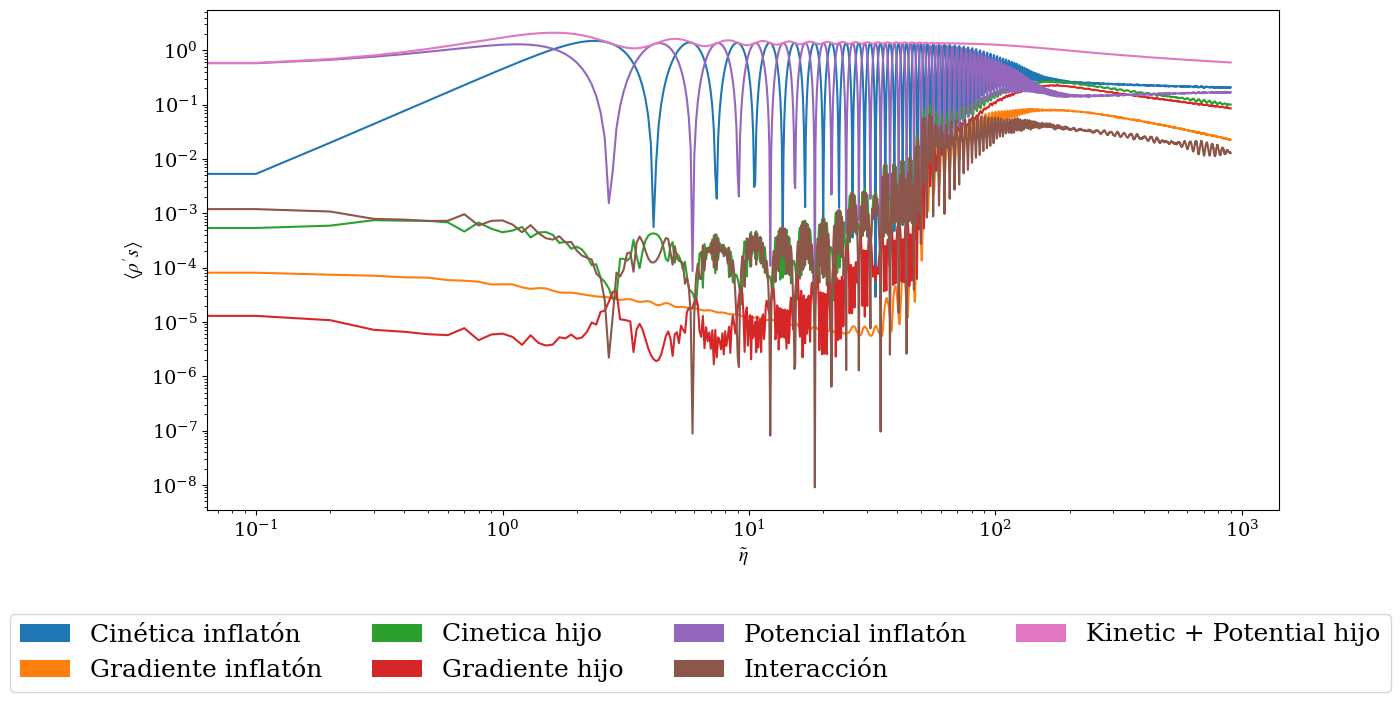

In [8]:
enDat = np.loadtxt(dir + "average_energies.txt")

nColumns = np.shape(enDat)[1]

# set explicitly different colors, so we know who is who
label = ["Cinética inflatón", "Gradiente inflatón", "Cinetica hijo", "Gradiente hijo", "Potencial inflatón", "Interacción", "Kinetic + Potential hijo"]
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown", "tab:pink"]

fig = plt.figure(figsize=(12, 6))

for i in range(1,nColumns):
    plt.plot(enDat[:,0], enDat[:,i]*aDat[:,1]**3, color = colors[i-1])
plt.yscale('log')
plt.xscale('log')
plt.xlabel("$\\tilde \eta$")
plt.ylabel("$\langle \\rho's\\rangle$")

plt.tight_layout()

# Crear leyenda general con los colores
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[i], label=label[i]) for i in range(len(label))]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.02), ncol=4, fontsize=18)

plt.show()

# Spectra

Spectra output varies depending on the option. The default one generates a txt file with the following columns:

$\tilde k$ | $\tilde\Delta_{\tilde\phi}$ | $\tilde\Delta_{\tilde\phi'}$ | $\tilde n_{\tilde\phi}$ | bin multiplicity

In [9]:
def load_spectrum(filename, comment = '#'):
    # The next few lines open the file and count
    # how many bins in one spectrum
    file = open(filename)
    nBins = 0
    # read first line
    line = file.readline()
    # while no blank we continue
    while line != "\n":
        # if not a comment line (header for instance)
        # we count one line
        if(line[0] != comment):
            nBins +=1
        # read next line
        line = file.readline()
    file.close()

    # now we know nBins. We still need to actually read the data.
    fileSp = np.loadtxt(filename, comments=comment)

    # find how many spectra are in the files
    nSpectra = len(fileSp) / nBins

    return fileSp, int(nBins), int(nSpectra)


def plot_spectrum(spectra, column, nBins, nSpectra, colormap='plasma'):
    colors = plt.get_cmap(colormap)
    norm = plt.Normalize(vmin=0, vmax=(nSpectra-1)*3)
    sm = plt.cm.ScalarMappable(cmap=colors, norm=norm)
    sm.set_array([])

    for i in range(nSpectra):
        plt.plot(
            spectra[i*nBins:(i+1)*nBins, 0],
            spectra[i*nBins:(i+1)*nBins, column],
            color=colors(i/nSpectra)
        )
    plt.xscale('log')
    plt.yscale('log')
    plt.grid(True, which="both", ls="--")
    plt.xlabel('$\\tilde k$', fontsize=20, labelpad=5)

    # Agrega la barra de colores asociada al eje actual
    cbar = plt.colorbar(sm, ax=plt.gca(), pad=0.02)
    cbar.set_label(r'$t$', fontsize=20, rotation=10)
    cbar.ax.tick_params(labelsize=16)

## Inflaton

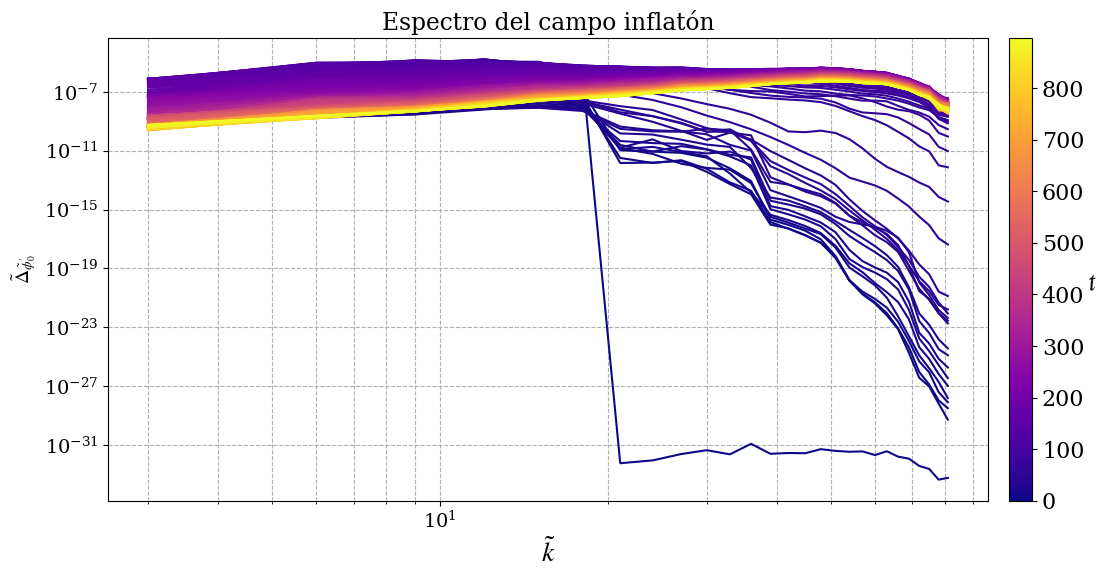

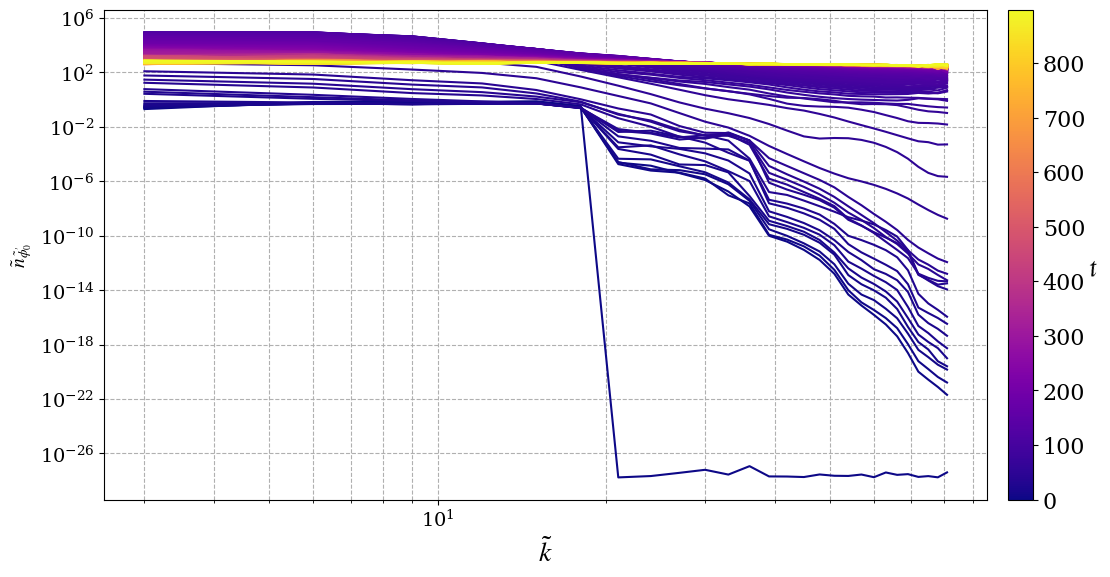

In [10]:
infSp, nBins, nSpectra = load_spectrum(dir + "spectra_scalar_0.txt")

plt.figure(figsize=(12, 6))

plot_spectrum(infSp, 1,  nBins, nSpectra)
plt.ylabel('$\\tilde\Delta_{\\tilde\phi_0\'}$')
plt.title(r'Espectro del campo inflatón')

plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 6))

plot_spectrum(infSp, 3,  nBins, nSpectra)
plt.ylabel('$\\tilde n_{\\tilde\phi_0\'}$')

plt.tight_layout()
plt.show()

## Daughter field

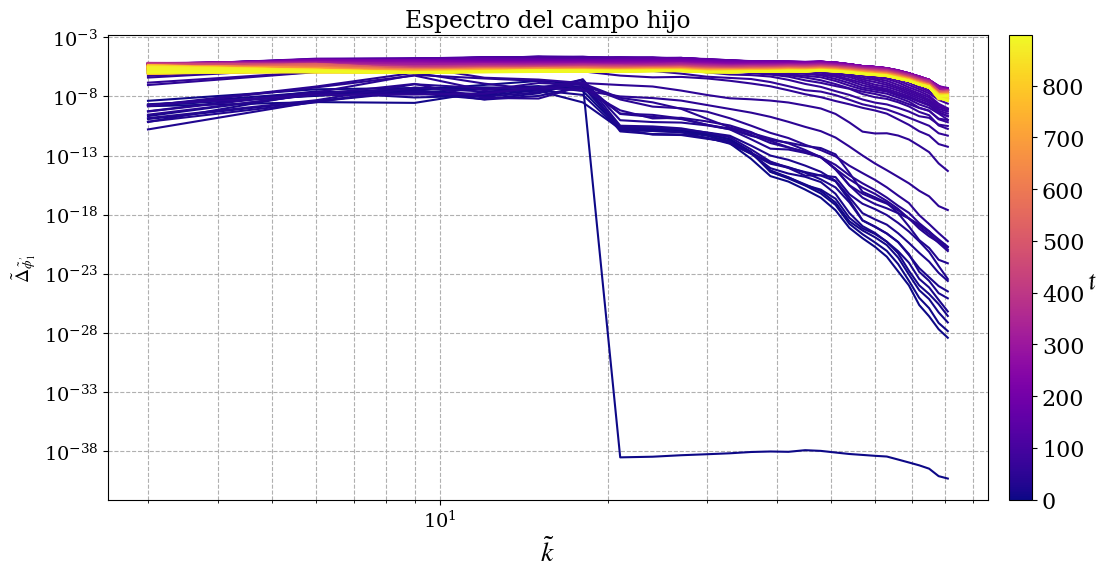

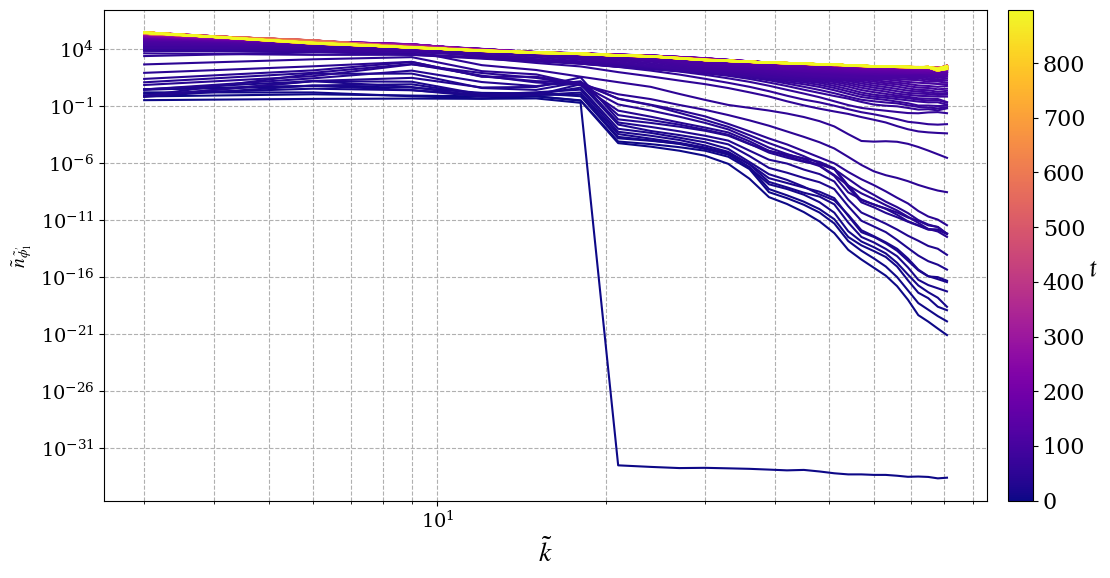

In [11]:
infSp, nBins, nSpectra = load_spectrum(dir + "spectra_scalar_1.txt")

plt.figure(figsize=(12, 6))

plot_spectrum(infSp, 1,  nBins, nSpectra)
plt.ylabel('$\\tilde\Delta_{\\tilde\phi_1\'}$')
plt.title(r'Espectro del campo hijo')

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))

plot_spectrum(infSp, 3,  nBins, nSpectra)
plt.ylabel('$\\tilde n_{\\tilde\phi_1\'}$')

plt.tight_layout()
plt.show()

# GWs

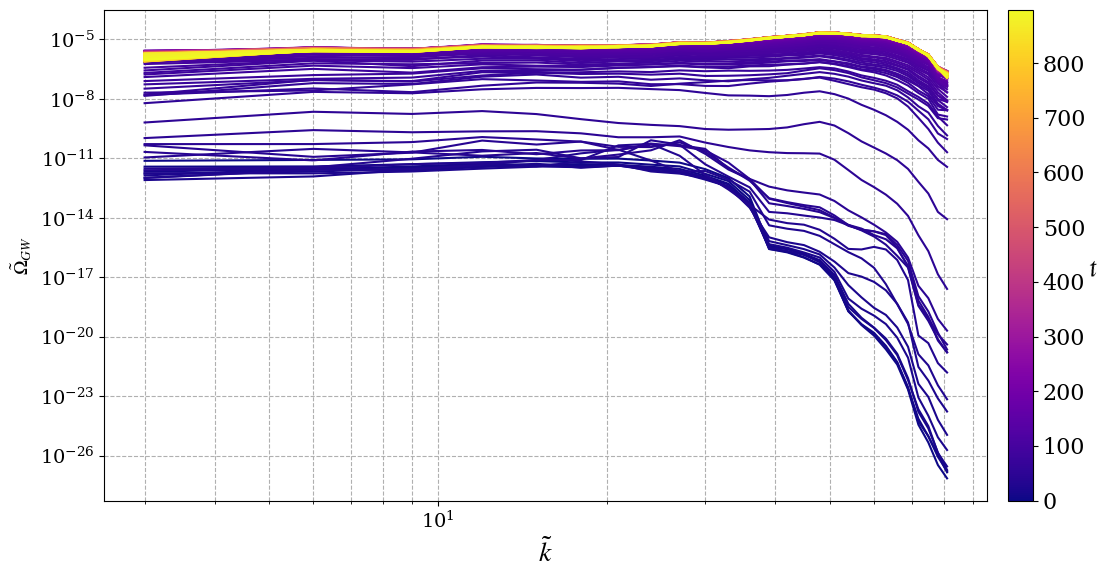

In [12]:
gwSp, nBins, nSpectra = load_spectrum(dir + "spectra_gws.txt")

plt.figure(figsize=(12, 6))

plot_spectrum(gwSp, 1,  nBins, nSpectra)
plt.ylabel('$\\tilde\Omega_{GW}$');

plt.tight_layout()
plt.show()

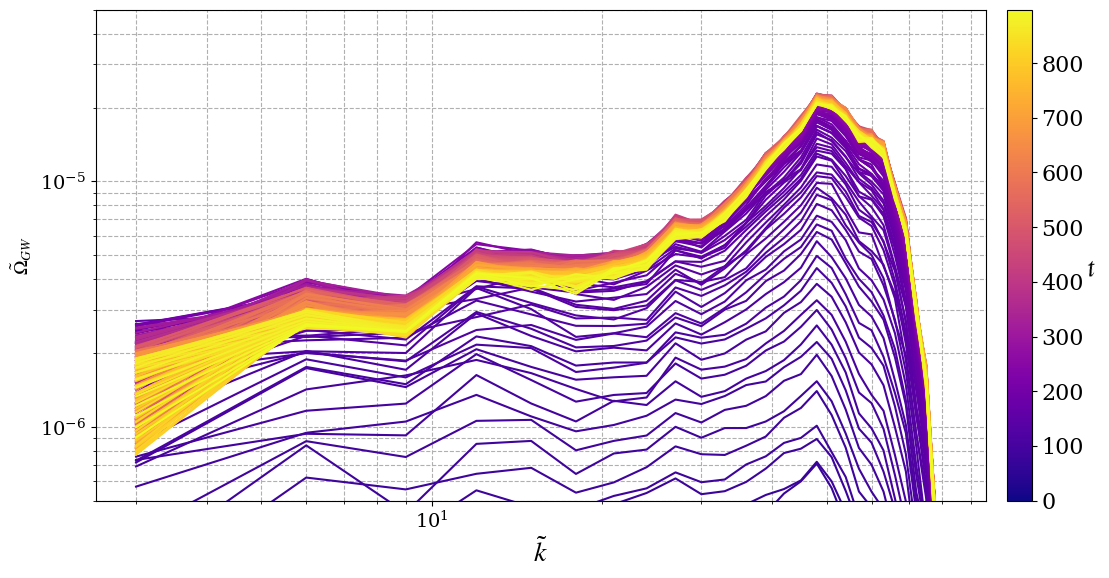

In [13]:
gwSp, nBins, nSpectra = load_spectrum(dir + "spectra_gws.txt")

plt.figure(figsize=(12, 6))

# --- LÓGICA DE ZOOM AUTOMÁTICO ---
columna_datos = 1 # Es la columna que pasas a plot_spectrum
# Extraemos solo los valores de esa columna
datos_y = gwSp[:, columna_datos]

# 1. Buscamos el máximo valor (ignorando posibles NaNs)
max_val = np.nanmax(datos_y)

# 2. Calculamos el orden de magnitud base
# Si max_val es 2e-14, magnitud_base será 1e-14
magnitud_base = 10**np.floor(np.log10(max_val))

# 3. Definimos los límites según tus reglas
y_max = 5 * magnitud_base
y_min = y_max / 100
# ---------------------------------

# Graficamos
plot_spectrum(gwSp, columna_datos, nBins, nSpectra)

# Aplicamos los límites calculados
plt.ylim(y_min, y_max)

plt.ylabel('$\\tilde\Omega_{GW}$');
plt.tight_layout()
plt.show()

In [14]:
def integrate_spectrum(spectrum, nBins, nSpectra):
    total_energy = []
    for i in range(nSpectra):
        energy = np.trapezoid(spectrum[i*nBins:(i+1)*nBins, 1], spectrum[i*nBins:(i+1)*nBins, 0])
        total_energy.append(energy)
    return total_energy

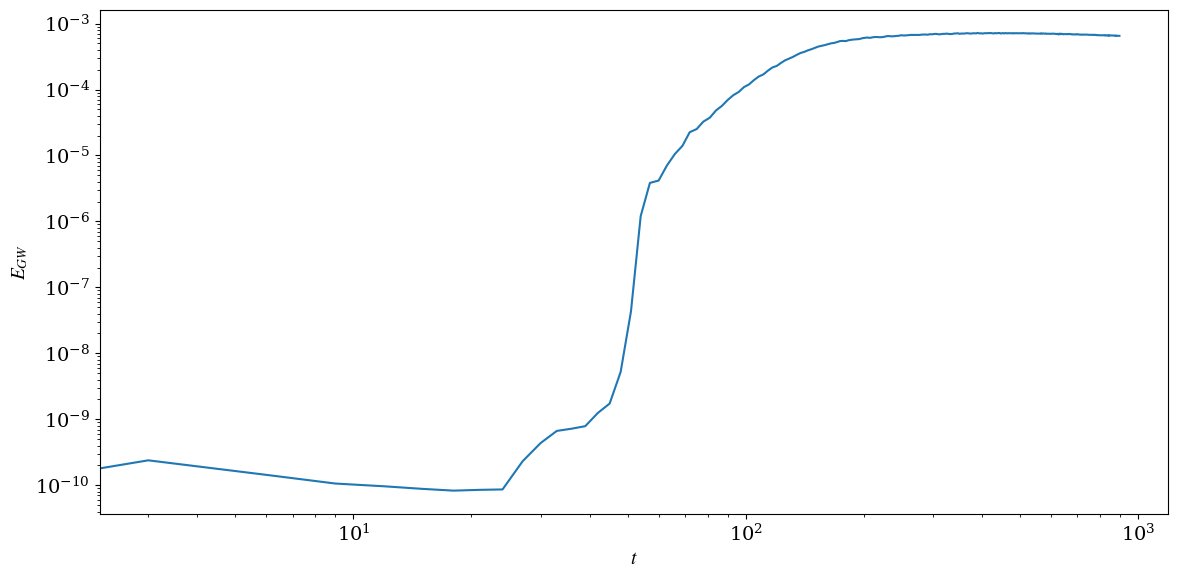

In [15]:
E = integrate_spectrum(gwSp, nBins, nSpectra)

plt.figure(figsize=(12, 6))

plt.plot(np.arange(nSpectra)*3, E)
plt.yscale('log')
plt.xscale('log') 
plt.xlabel(r'$t$')
plt.ylabel(r'$E_{GW}$')

plt.tight_layout()
plt.show()

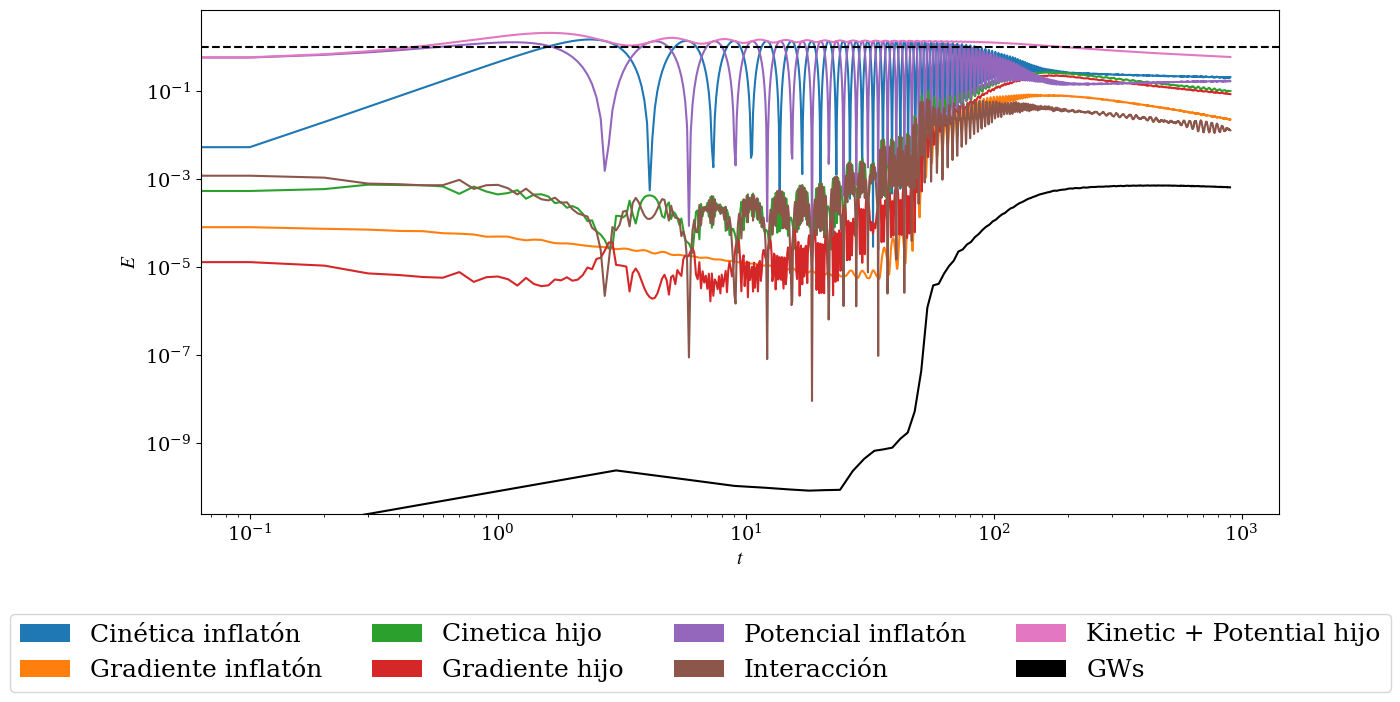

In [16]:
fig = plt.figure(figsize=(12, 6))

label = ["Cinética inflatón", "Gradiente inflatón", "Cinetica hijo", "Gradiente hijo", "Potencial inflatón", "Interacción", "Kinetic + Potential hijo", "GWs"]
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown", "tab:pink", "black"]

for i in range(1,nColumns):
    plt.plot(enDat[:,0], enDat[:,i]*aDat[:,1]**3, color = colors[i-1])
plt.plot(np.arange(nSpectra)*3, E, color = 'black')
plt.axhline(y = 1, ls = "--", color = "black")
plt.yscale('log')
plt.xscale('log')
plt.xlabel(r'$t$')
plt.ylabel(r'$E$')

plt.tight_layout()

# Crear leyenda general con los colores
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[i], label=label[i]) for i in range(len(label))]
fig.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.02), ncol=4, fontsize=18)

plt.show()

# Cálculo de Tiempo característico GWs

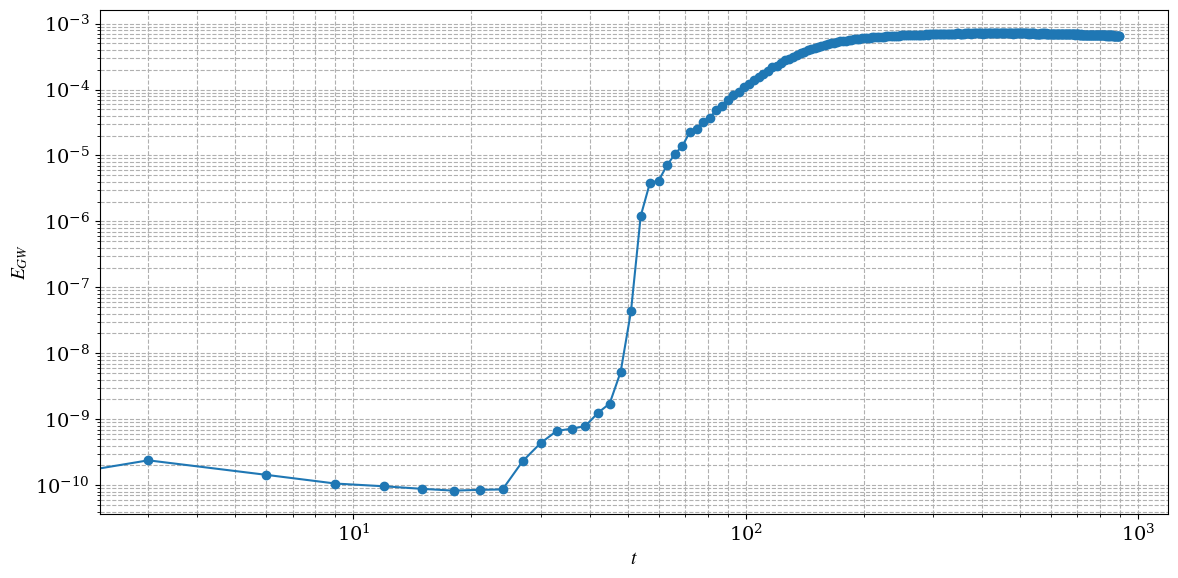

In [17]:
E = integrate_spectrum(gwSp, nBins, nSpectra)

plt.figure(figsize=(12, 6))

plt.plot(np.arange(nSpectra)*3, E, "-o")
plt.yscale('log')
plt.xscale('log') 
plt.xlabel(r'$t$')
plt.ylabel(r'$E_{GW}$')
plt.grid(True, which="both", ls="--")
plt.tight_layout()
plt.show()

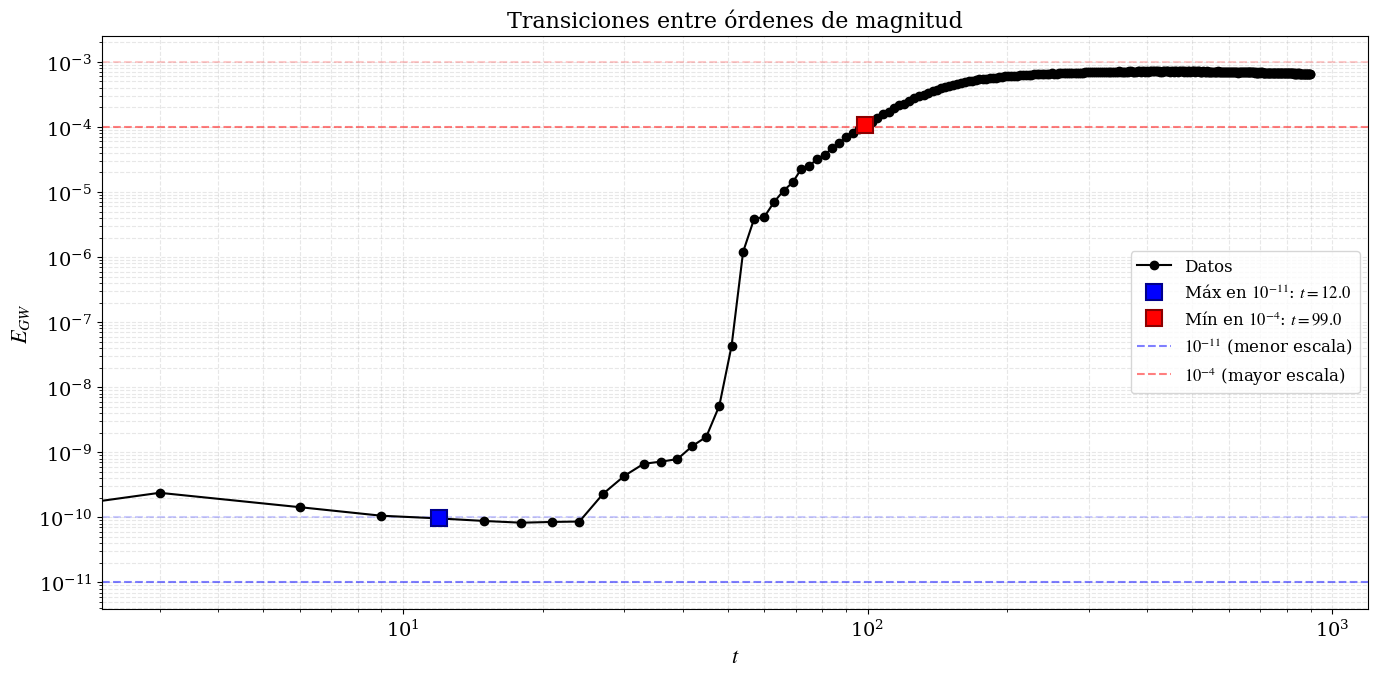

                  ANÁLISIS DE TRANSICIONES DE ESCALA                  
Valores procesados: 299/300
Rango de órdenes de magnitud: 10^-11 a 10^-4

1. PUNTO MÁS GRANDE CON MENOR ORDEN DE MAGNITUD (10^-11):
   Índice:  4
   Tiempo:  t = 12.00
   Energía: E = 9.641654e-11

2. PUNTO MÁS PEQUEÑO CON MAYOR ORDEN DE MAGNITUD (10^-4):
   Índice:  33
   Tiempo:  t = 99.00
   Energía: E = 1.088212e-04

Intervalo de tiempo entre transiciones: Δt = 87.00
Ratio de energías: E_min_in_max / E_max_in_min = 1.13e+06


In [18]:
import numpy as np
import matplotlib.pyplot as plt

def analyze_scale_transitions(t_data, E_data):
    """
    Identifica transiciones entre órdenes de magnitud en los datos de energía.
    Filtra automáticamente valores no válidos (≤ 0 o NaN).
    """
    # Asegurar que sean arrays de numpy y del tipo correcto
    E_data = np.asarray(E_data, dtype=float)
    t_data = np.asarray(t_data, dtype=float)
    
    # Máscara para filtrar valores válidos
    valid_mask = (E_data > 0) & np.isfinite(E_data) & np.isfinite(t_data)
    valid_indices = np.where(valid_mask)[0] # Índices originales de los datos válidos
    
    if len(valid_indices) == 0:
        print("ERROR: No hay valores válidos para analizar")
        return None
    
    E_valid = E_data[valid_indices]
    t_valid = t_data[valid_indices]
    
    # Calcular órdenes de magnitud
    magnitudes = np.floor(np.log10(E_valid))
    min_magnitude = int(magnitudes.min())
    max_magnitude = int(magnitudes.max())
    
    # Agrupar los índices locales según su orden de magnitud
    idx_min_mag_group = np.where(magnitudes == min_magnitude)[0]
    idx_max_mag_group = np.where(magnitudes == max_magnitude)[0]
    
    # Encontrar el MÁXIMO dentro de la magnitud MÍNIMA
    local_max_in_min = np.argmax(E_valid[idx_min_mag_group])
    idx_max_in_min = valid_indices[idx_min_mag_group[local_max_in_min]] # Mapeo al índice original
    
    # Encontrar el MÍNIMO dentro de la magnitud MÁXIMA
    local_min_in_max = np.argmin(E_valid[idx_max_mag_group])
    idx_min_in_max = valid_indices[idx_max_mag_group[local_min_in_max]] # Mapeo al índice original
    
    return {
        'min_magnitude': min_magnitude,
        'max_magnitude': max_magnitude,
        'idx_max_in_min': idx_max_in_min,
        't_max_in_min': t_data[idx_max_in_min],
        'E_max_in_min': E_data[idx_max_in_min],
        'idx_min_in_max': idx_min_in_max,
        't_min_in_max': t_data[idx_min_in_max],
        'E_min_in_max': E_data[idx_min_in_max],
        'n_valid': len(valid_indices),
        'n_total': len(E_data),
    }

def plot_scale_transitions(t_data, E_data, analysis, ax=None):
    """
    Genera el gráfico de las transiciones. Permite inyectar un eje (ax) 
    para integrarlo fácilmente en subplots de Matplotlib.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 6)) # Usa el figsize por defecto de tu notebook
        
    ax.plot(t_data, E_data, 'o-', markersize=6, label='Datos', color='black', linewidth=1.5, zorder=3)

    # Extraer variables para legibilidad
    idx1, t1, E1, mag_min = analysis['idx_max_in_min'], analysis['t_max_in_min'], analysis['E_max_in_min'], analysis['min_magnitude']
    idx2, t2, E2, mag_max = analysis['idx_min_in_max'], analysis['t_min_in_max'], analysis['E_min_in_max'], analysis['max_magnitude']

    # Marcar puntos clave usando strings crudos (fr"") para mejor compatibilidad con tu fuente 'stix'
    ax.plot(t1, E1, 's', markersize=12, 
             label=fr"Máx en $10^{{{mag_min}}}$: $t={t1:.1f}$", 
             color='blue', zorder=4, markeredgecolor='darkblue', markeredgewidth=1.5)

    ax.plot(t2, E2, 's', markersize=12, 
             label=fr"Mín en $10^{{{mag_max}}}$: $t={t2:.1f}$", 
             color='red', zorder=4, markeredgecolor='darkred', markeredgewidth=1.5)

    # Líneas horizontales de órdenes de magnitud
    ax.axhline(10**mag_min, color='blue', linestyle='--', lw=1.5, alpha=0.5, label=fr"$10^{{{mag_min}}}$ (menor escala)")
    ax.axhline(10**(mag_min+1), color='blue', linestyle='--', lw=1.5, alpha=0.2)

    ax.axhline(10**mag_max, color='red', linestyle='--', lw=1.5, alpha=0.5, label=fr"$10^{{{mag_max}}}$ (mayor escala)")
    ax.axhline(10**(mag_max+1), color='red', linestyle='--', lw=1.5, alpha=0.2)

    ax.set_yscale('log')
    ax.set_xscale('log')
    ax.set_xlabel(r'$t$', fontsize=16)
    ax.set_ylabel(r'$E_{GW}$', fontsize=16)
    ax.set_title('Transiciones entre órdenes de magnitud', fontsize=16)
    ax.legend(fontsize=12, loc='best')
    ax.grid(True, which="both", ls="--", alpha=0.3)
    
    if ax is None:
        plt.tight_layout()
        plt.show()
        
    return ax

def print_scale_analysis(analysis):
    """
    Imprime el reporte en la consola de forma estructurada.
    """
    print("=" * 70)
    print(f"{'ANÁLISIS DE TRANSICIONES DE ESCALA':^70}") # Centrado automático
    print("=" * 70)
    print(f"Valores procesados: {analysis['n_valid']}/{analysis['n_total']}")
    print(f"Rango de órdenes de magnitud: 10^{analysis['min_magnitude']} a 10^{analysis['max_magnitude']}\n")
    
    print(f"1. PUNTO MÁS GRANDE CON MENOR ORDEN DE MAGNITUD (10^{analysis['min_magnitude']}):")
    print(f"   Índice:  {analysis['idx_max_in_min']}")
    print(f"   Tiempo:  t = {analysis['t_max_in_min']:.2f}")
    print(f"   Energía: E = {analysis['E_max_in_min']:.6e}\n")
    
    print(f"2. PUNTO MÁS PEQUEÑO CON MAYOR ORDEN DE MAGNITUD (10^{analysis['max_magnitude']}):")
    print(f"   Índice:  {analysis['idx_min_in_max']}")
    print(f"   Tiempo:  t = {analysis['t_min_in_max']:.2f}")
    print(f"   Energía: E = {analysis['E_min_in_max']:.6e}\n")
    
    dt = analysis['t_min_in_max'] - analysis['t_max_in_min']
    e_ratio = analysis['E_min_in_max'] / analysis['E_max_in_min']
    
    print(f"Intervalo de tiempo entre transiciones: Δt = {dt:.2f}")
    print(f"Ratio de energías: E_min_in_max / E_max_in_min = {e_ratio:.2e}")
    print("=" * 70)

t_gw = np.arange(nSpectra) * 3
analysis = analyze_scale_transitions(t_gw, E)

if analysis is not None:
    # 1. Mostrar gráfico
    plt.figure(figsize=(14, 7))
    ax = plt.gca()
    plot_scale_transitions(t_gw, E, analysis, ax=ax)
    plt.tight_layout()
    plt.show()
    
    # 2. Mostrar reporte de texto
    print_scale_analysis(analysis)

# Transformación del espectro a lo medido hoy en frecuencia física

Para hacer el reescaleo al espectro que medimos el día de hoy podemos usar la siguiente transformación:

$$\Omega_{GW} = \Omega_{RAD,0} \frac{g_{reh}}{g_0} \left( \frac{g_{s,0}}{g_{s,reh}} \right)^{4/3} \left( \frac{\pi^2 g_{reh} T^4_{reh}}{60 V_i} \right)^{\frac{1 - 3\omega}{3(1 + \omega)}} \left( \frac{a_f}{a_i} \right)^{1 - 3\omega} \Omega_{GW} (k, a_f)$$

Y a su vez, para pasar de momento comovil $k$ a frecuencia hoy tenemos:

$$f_0 = \frac{\omega_*}{2\pi} \frac{g_{s,0}}{g_{s,reh}} \left( \frac{\pi^2 g_{reh}}{60 V_i} \right)^{\frac{1}{3(1 + \omega)}} T_0 T^{\frac{1 - 3\omega}{3(1 + \omega)}}_{reh} \tilde{k}$$

In [19]:
"""Variables"""
Omega_RAD = 8.6e-5
greh = 106.5
g0 = 3.36
gs0 = 3.91
gsreh = 106.5
h = 4.134e-24                            #GeV*s
kB = 8.617333e-14                        #GeV/K
Treh = 1e14                              #GeV
T0 = 2.726 * kB                          #GeV
omega = 0                                #MAT

m = 1.46e13                              #GeV
omegaStar = m
nindex = 48
phi0 = 3.44e18                           #GeV
fStar = phi0
ai, af = aDat[0,1], aDat[nindex,1]
Vi = enDat[0,5]*(fStar**2*omegaStar**2)  #Potencial inicial del inflatón, que es el que domina la energía al principio

"""Escaleos"""
f0 = omegaStar/(2 * np.pi * h) * (gs0/gsreh) * (np.pi**2*greh/(60*Vi))**(1/(3*(1+omega))) * T0 * Treh**((1 - 3*omega)/(3*(1+omega)))
Omega0 = Omega_RAD * greh/g0 * (gs0/gsreh)**(4/3) * (np.pi**2 * greh * Treh**4/(60*Vi))**((1 - 3*omega)/(3*(1+omega))) * (af/ai)**(1 - 3*omega)

In [20]:
print(Omega0, f0)

LHS = Vi * (ai/af)**3
RHS = np.pi**2 * greh * Treh**4

print(LHS, RHS)

TMAX = (LHS/(np.pi**2 * greh))**(1/4)
print("Treh máximo:", "{:.2e}".format(TMAX))

1.4786886856157456e-06 543211.6376302935
1.9938973523449312e+61 1.0511128687160169e+59
Treh máximo: 3.71e+14


In [21]:
def load_spectrum(filename, comment = '#'):
    # The next few lines open the file and count
    # how many bins in one spectrum
    file = open(filename)
    nBins = 0
    # read first line
    line = file.readline()
    # while no blank we continue
    while line != "\n":
        # if not a comment line (header for instance)
        # we count one line
        if(line[0] != comment):
            nBins +=1
        # read next line
        line = file.readline()
    file.close()

    # now we know nBins. We still need to actually read the data.
    fileSp = np.loadtxt(filename, comments=comment)

    # find how many spectra are in the files
    nSpectra = len(fileSp) / nBins

    return fileSp, int(nBins), int(nSpectra)


def plot_spectrum_today(spectra, column, nBins, nSpectra, spectrum_index=None, colormap='plasma'):
    colors = plt.get_cmap(colormap)
    norm = plt.Normalize(vmin=0, vmax=(nSpectra-1)*3)
    sm = plt.cm.ScalarMappable(cmap=colors, norm=norm)
    sm.set_array([])

    if spectrum_index is None:
        indices = range(nSpectra)
    else:
        if spectrum_index < 0 or spectrum_index >= nSpectra:
            raise ValueError(f"spectrum_index must be between 0 and {nSpectra-1}")
        indices = [spectrum_index]

    for i in indices:
        plt.plot(
            spectra[i*nBins:(i+1)*nBins, 0]*f0,
            spectra[i*nBins:(i+1)*nBins, column]*Omega0,
            color=colors(i/nSpectra)
        )
    plt.xscale('log')
    plt.yscale('log')
    plt.grid(True, which="both", ls="--")
    plt.xlabel(r'$f_0$ [Hz]', fontsize=20, labelpad=5)

    if spectrum_index is None:
        # Agrega la barra de colores asociada al eje actual
        cbar = plt.colorbar(sm, ax=plt.gca(), pad=0.02)
        cbar.set_label(r'$t$', fontsize=20, rotation=10)
        cbar.ax.tick_params(labelsize=16)

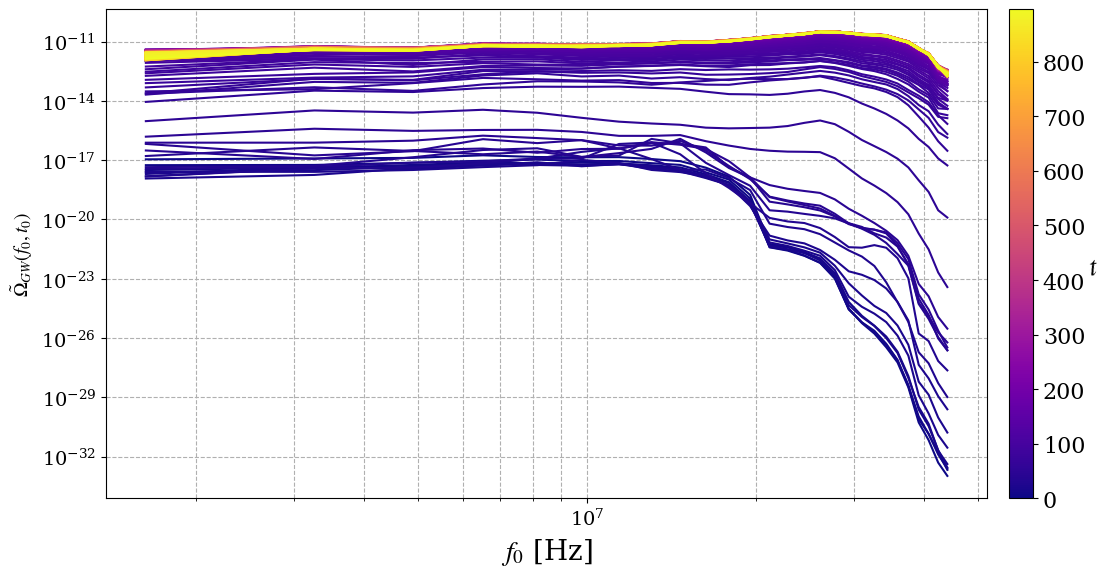

In [22]:
gwSp, nBins, nSpectra = load_spectrum(dir + "spectra_gws.txt")

plt.figure(figsize=(12, 6))

plot_spectrum_today(gwSp, 1,  nBins, nSpectra, None)#nindex)
plt.ylabel(r'$\tilde\Omega_{GW} (f_0, t_0)$');

plt.tight_layout()
plt.show()

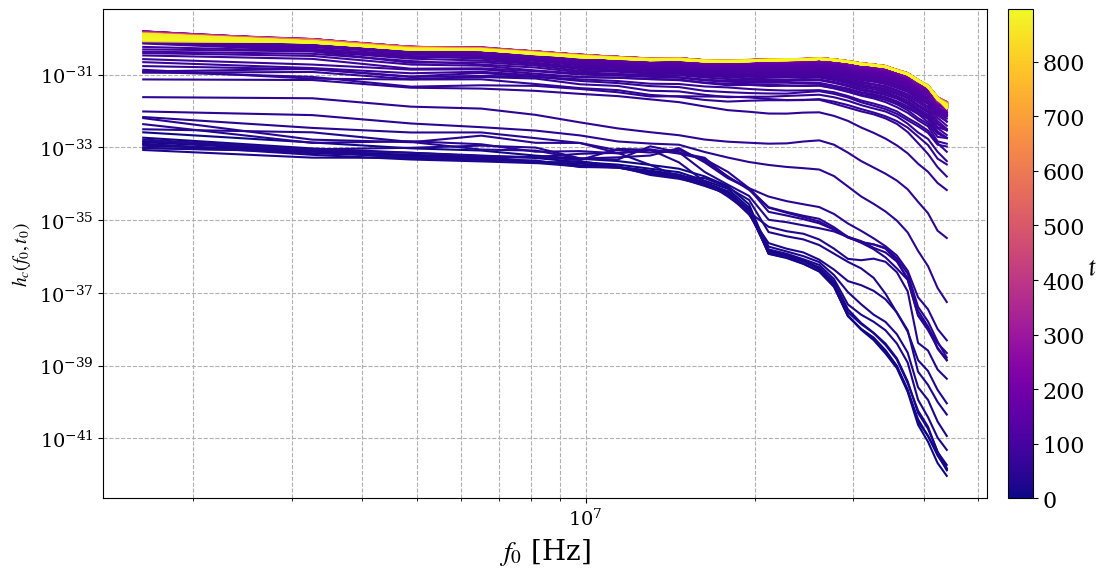

In [23]:
"""Strain"""
H0 = 2.3e-18 #Hz

def plot_strain(spectra, column, nBins, nSpectra, spectrum_index=None, colormap='plasma'):
    colors = plt.get_cmap(colormap)
    norm = plt.Normalize(vmin=0, vmax=(nSpectra-1)*3)
    sm = plt.cm.ScalarMappable(cmap=colors, norm=norm)
    sm.set_array([])

    if spectrum_index is None:
        indices = range(nSpectra)
    else:
        if spectrum_index < 0 or spectrum_index >= nSpectra:
            raise ValueError(f"spectrum_index must be between 0 and {nSpectra-1}")
        indices = [spectrum_index]

    for i in indices:
        plt.plot(
            spectra[i*nBins:(i+1)*nBins, 0]*f0,
            np.sqrt(spectra[i*nBins:(i+1)*nBins, column]*Omega0)*np.sqrt(3)/np.pi*H0/(spectra[i*nBins:(i+1)*nBins, 0]*f0),
            color=colors(i/nSpectra)
        )
    plt.xscale('log')
    plt.yscale('log')
    plt.grid(True, which="both", ls="--")
    plt.xlabel(r'$f_0$ [Hz]', fontsize=20, labelpad=5)

    if spectrum_index is None:
        # Agrega la barra de colores asociada al eje actual
        cbar = plt.colorbar(sm, ax=plt.gca(), pad=0.02)
        cbar.set_label(r'$t$', fontsize=20, rotation=10)
        cbar.ax.tick_params(labelsize=16)

plt.figure(figsize=(12, 6))
plot_strain(gwSp, 1,  nBins, nSpectra, None)#n_index)
plt.ylabel(r'$h_c(f_0, t_0)$');
plt.tight_layout()
plt.show()

In [24]:
"""Guardar espectro hc del tiempo mayor"""
# Índice del último espectro (tiempo mayor)
spectrum_index = nSpectra - 1

# Extraer los datos para ese espectro
k_index = np.arange(spectrum_index * nBins, (spectrum_index + 1) * nBins)
f_today = gwSp[k_index, 0] * f0/5e2
h_c = np.sqrt(gwSp[k_index, 1] * Omega0) * np.sqrt(3) / np.pi * H0 / f_today

# Crear matriz con x e y
data_to_save = np.column_stack((f_today, h_c))

# Guardar en archivo
output_file = "strain_spectrum_tanh2.txt"
np.savetxt(output_file, data_to_save, header='f_0 [Hz]            h_c(f_0, t_0)', fmt='%.6e')

print(f"Espectro guardado en: {output_file}")
print(f"Tiempo del espectro: t = {spectrum_index * 3}")
print(f"Filas: {len(data_to_save)}")

Espectro guardado en: strain_spectrum_tanh2.txt
Tiempo del espectro: t = 897
Filas: 27


In [25]:
"""Leer y verificar que el archivo se guardó correctamente"""
# Leer el archivo guardado
data_loaded = np.loadtxt(output_file)

print("=" * 70)
print("VERIFICACIÓN DE ARCHIVO GUARDADO")
print("=" * 70)
print(f"Archivo: {output_file}")
print(f"Forma: {data_loaded.shape}")
print(f"\nPrimeras 5 filas:")
print(f"{'f_0 [Hz]':<20} {'h_c(f_0, t_0)':<20}")
for i in range(min(5, len(data_loaded))):
    print(f"{data_loaded[i, 0]:<20.6e} {data_loaded[i, 1]:<20.6e}")
print(f"\nÚltimas 5 filas:")
for i in range(max(0, len(data_loaded) - 5), len(data_loaded)):
    print(f"{data_loaded[i, 0]:<20.6e} {data_loaded[i, 1]:<20.6e}")
print(f"\nRango de f_0: {data_loaded[:, 0].min():.6e} - {data_loaded[:, 0].max():.6e}")
print(f"Rango de h_c: {data_loaded[:, 1].min():.6e} - {data_loaded[:, 1].max():.6e}")
print("=" * 70)

VERIFICACIÓN DE ARCHIVO GUARDADO
Archivo: strain_spectrum_tanh2.txt
Forma: (27, 2)

Primeras 5 filas:
f_0 [Hz]             h_c(f_0, t_0)       
3.259270e+03         4.505611e-28        
6.518540e+03         3.820899e-28        
9.777809e+03         2.473324e-28        
1.303708e+04         2.429534e-28        
1.629635e+04         1.898917e-28        

Últimas 5 filas:
7.496321e+04         5.182657e-29        
7.822248e+04         3.417087e-29        
8.148175e+04         2.361683e-29        
8.474102e+04         1.081435e-29        
8.800029e+04         7.260547e-30        

Rango de f_0: 3.259270e+03 - 8.800029e+04
Rango de h_c: 7.260547e-30 - 4.505611e-28


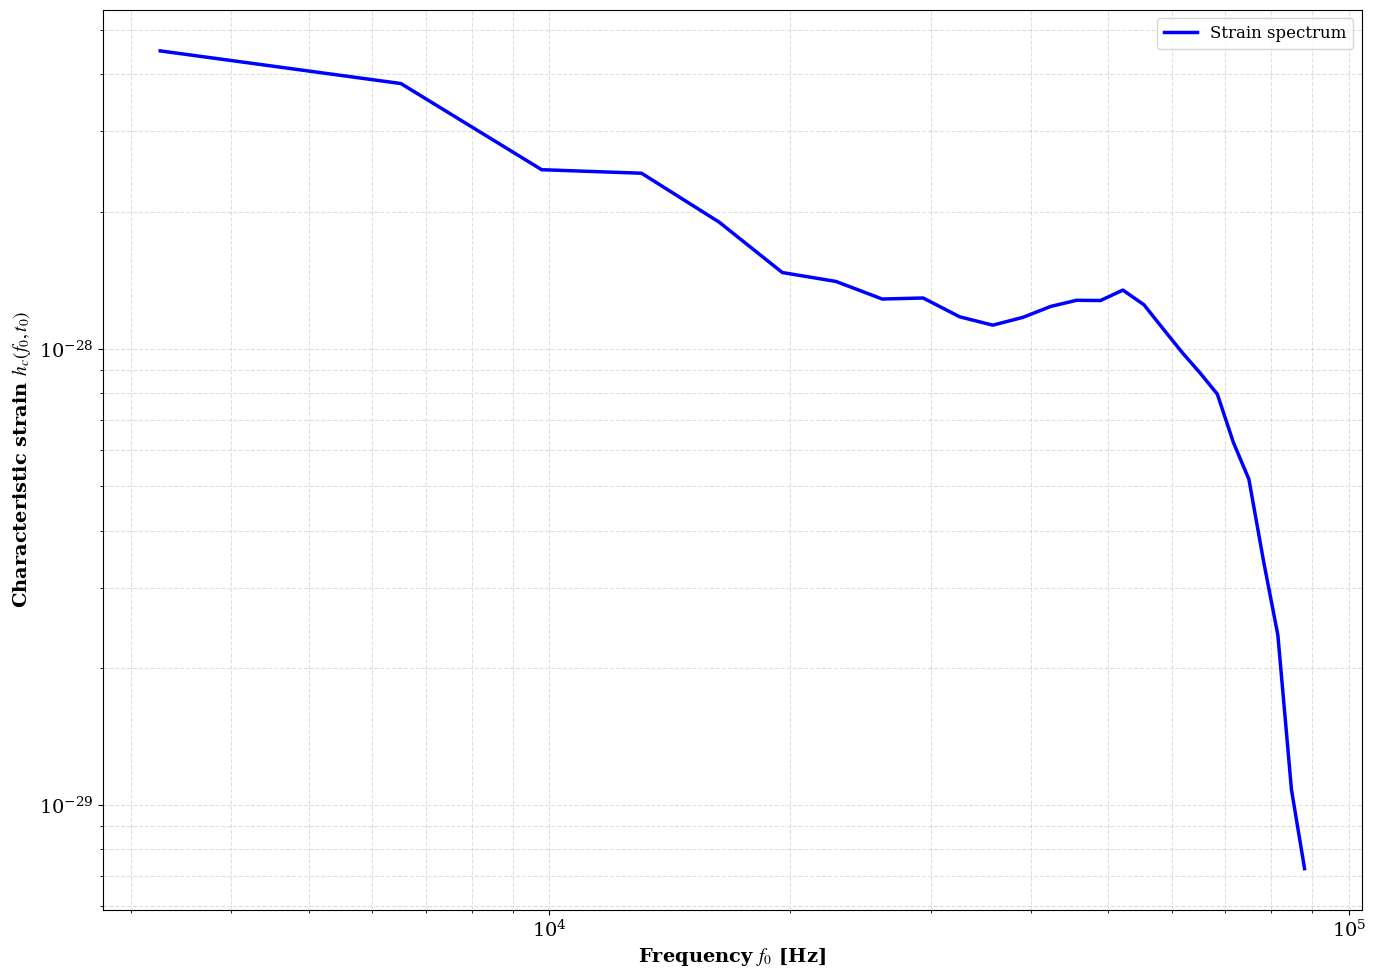


ESTADÍSTICAS DEL ESPECTRO
Número de puntos: 27
Frecuencia mínima: 3.259270e+03 Hz
Frecuencia máxima: 8.800029e+04 Hz

Strain mínimo: 7.260547e-30
Strain máximo: 4.505611e-28
Strain promedio: 1.338126e-28

Frequencia en peak: 3.259270e+03 Hz
Strain en peak: 4.505611e-28


In [26]:
"""Ploteo mejorado del espectro h_c guardado"""
fig, ax1 = plt.subplots(1, 1, figsize=(14, 10))

# --- Subplot 1: Escala log-log (típico para espectros GW) ---
ax1.loglog(data_loaded[:, 0], data_loaded[:, 1], 'b-', linewidth=2.5, label='Strain spectrum')
ax1.grid(True, which='both', linestyle='--', alpha=0.4)
ax1.set_xlabel(r'Frequency $f_0$ [Hz]', fontsize=14, fontweight='bold')
ax1.set_ylabel(r'Characteristic strain $h_c(f_0, t_0)$', fontsize=14, fontweight='bold')
ax1.legend(fontsize=12, loc='best')


plt.tight_layout()
plt.show()

# --- Estadísticas ---
print("\nESTADÍSTICAS DEL ESPECTRO")
print("=" * 70)
print(f"Número de puntos: {len(data_loaded)}")
print(f"Frecuencia mínima: {data_loaded[:, 0].min():.6e} Hz")
print(f"Frecuencia máxima: {data_loaded[:, 0].max():.6e} Hz")
print(f"\nStrain mínimo: {data_loaded[:, 1].min():.6e}")
print(f"Strain máximo: {data_loaded[:, 1].max():.6e}")
print(f"Strain promedio: {data_loaded[:, 1].mean():.6e}")
print(f"\nFrequencia en peak: {data_loaded[np.argmax(data_loaded[:, 1]), 0]:.6e} Hz")
print(f"Strain en peak: {data_loaded[:, 1].max():.6e}")
print("=" * 70)